# VD genre data from VD16, VD17, VD18

This notebook is analyzing the genre data in the VD16, VD17, and VD18 datasets.

Genre code: field_code=044S, subfield_code=a

Time code: field_code=011@, subfield_code=a

City code: field_code=033A, subfield_code=p

standardized location: field_code=033D, subfield_code=p

In [ ]:
# Loading the data from the .parquet files
# also import the packages needed

from pathlib import Path
import re
import duckdb
import narwhals as nw
from hereutil import here
from typing import Callable, cast
from tqdm.auto import tqdm

import pandas as pd

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

con = duckdb.connect(config=dict(parquet_metadata_cache=True, preserve_insertion_order=False, enable_fsst_vectors=True))
con.sql("SET enable_progress_bar=true;")

vd16 = cast(nw.LazyFrame[duckdb.DuckDBPyRelation], None)
vd17 = cast(nw.LazyFrame[duckdb.DuckDBPyRelation], None)
vd18 = cast(nw.LazyFrame[duckdb.DuckDBPyRelation], None)

c = nw.col
l = nw.lit

def to_narwhals(duckdb_table: duckdb.DuckDBPyRelation) -> nw.LazyFrame[duckdb.DuckDBPyRelation]:
    return nw.from_native(duckdb_table)

def read_parquet(table_name: str, *paths: Path) -> nw.LazyFrame[duckdb.DuckDBPyRelation]:
    if len(paths) == 1:
        files_sql = f"'{paths[0]}'"
    else:
        files_sql = "[" + ", ".join(f"'{p}'" for p in paths) + "]"
    con.sql(f"CREATE OR REPLACE VIEW {table_name} AS SELECT * FROM read_parquet({files_sql});")
    return to_narwhals(con.view(table_name))

groups: dict[str, list] = {}

print(here("data/work"))
print(here("data/work").exists())

for file in here(f"data/work").glob("*/*.parquet"):
    print(file)
    table_name = re.sub(r"_\d+$", "", file.stem)
    groups.setdefault(table_name, []).append(file)

for table_name, files in (pbar := tqdm(groups.items())):
    pbar.set_description(f"Registering {table_name}")
    globals()[table_name] = read_parquet(table_name, *files)
    print(f"{table_name} = cast(nw.LazyFrame[DuckDBPyRelation], None)")

/home/hgavert/University/Hackaton/books/data/work
True
/home/hgavert/University/Hackaton/books/data/work/wikidata/wd_descriptions.parquet
/home/hgavert/University/Hackaton/books/data/work/wikidata/wd_claim_wikibase_entityid.parquet
/home/hgavert/University/Hackaton/books/data/work/wikidata/wd_claim_globecoordinate.parquet
/home/hgavert/University/Hackaton/books/data/work/wikidata/wd_claim_time.parquet
/home/hgavert/University/Hackaton/books/data/work/wikidata/wd_claim_monolingualtext.parquet
/home/hgavert/University/Hackaton/books/data/work/wikidata/wd_aliases.parquet
/home/hgavert/University/Hackaton/books/data/work/wikidata/wd_entities.parquet
/home/hgavert/University/Hackaton/books/data/work/wikidata/wd_labels.parquet
/home/hgavert/University/Hackaton/books/data/work/vd17/vd17.parquet
/home/hgavert/University/Hackaton/books/data/work/vd18/vd18.parquet
/home/hgavert/University/Hackaton/books/data/work/vd16/vd16.parquet


  0%|          | 0/11 [00:00<?, ?it/s]

wd_descriptions = cast(nw.LazyFrame[DuckDBPyRelation], None)
wd_claim_wikibase_entityid = cast(nw.LazyFrame[DuckDBPyRelation], None)
wd_claim_globecoordinate = cast(nw.LazyFrame[DuckDBPyRelation], None)
wd_claim_time = cast(nw.LazyFrame[DuckDBPyRelation], None)
wd_claim_monolingualtext = cast(nw.LazyFrame[DuckDBPyRelation], None)
wd_aliases = cast(nw.LazyFrame[DuckDBPyRelation], None)
wd_entities = cast(nw.LazyFrame[DuckDBPyRelation], None)
wd_labels = cast(nw.LazyFrame[DuckDBPyRelation], None)
vd17 = cast(nw.LazyFrame[DuckDBPyRelation], None)
vd18 = cast(nw.LazyFrame[DuckDBPyRelation], None)
vd16 = cast(nw.LazyFrame[DuckDBPyRelation], None)


In [30]:
# Genres in the VD datasets

result = (
    nw.concat([
        #vd16.with_columns(l("vd16").alias("source")),
        #vd17.with_columns(l("vd16").alias("source")),
        vd18.with_columns(l("vd18").alias("source")),
    ])
    .filter(c("field_code") == "033D")
    .filter(c("subfield_code") == "p")
    .collect()
)
df = result.to_pandas()
print(df["value"].value_counts())

value
Leipzig                                                                                  83576
Berlin                                                                                   26801
Jena                                                                                     20305
Wittenberg                                                                               17828
Wien                                                                                     15990
Halle, Saale                                                                             15667
Halle (Saale)                                                                            15275
Göttingen                                                                                14376
Hamburg                                                                                  14176
Dresden                                                                                  12723
Frankfurt am Main                           

In [ ]:
# Genre counts in the different VD datasets

def get_value_counts(lf: nw.LazyFrame, dataset_name: str) -> pd.DataFrame:
    return (
        lf.filter(
            (c("field_code") == l("044S")) & 
            (c("subfield_code") == l("a"))
        )
        .group_by("value")
        .agg(c("value").count().alias(f"count_{dataset_name}"))
        .collect()
        .to_pandas()
    )

df16 = get_value_counts(vd16, "vd16")
df17 = get_value_counts(vd17, "vd17")
df18 = get_value_counts(vd18, "vd18")

result = (
    df16
    .merge(df17, on="value", how="outer")
    .merge(df18, on="value", how="outer")
    .sort_values("value")
    .fillna(0)
    .astype({"count_vd16": int, "count_vd17": int, "count_vd18": int})
    .reset_index(drop=True)
)
display_result = result.copy()
display_result["value"] = display_result["value"].str[:500]  # adjust width as needed
print(display_result.to_string(index=False))

display_result.to_csv("genres_vd.csv", index=False)

                                                                                                                                                                                                                                                                                                                                                                                                                                       value  count_vd16  count_vd17  count_vd18
                                                                                                                                                                                                                                                                                                                                                                                                                                                       4          18           0
                                                                      

In [ ]:
# Genre coverage in the VD datasets

# Load the CSV
genre_df = pd.read_csv(here("data/input/hackathon_genre_categorization.csv"))
canonical_genres = set(genre_df["german_genre_term"].dropna().str.strip())

def coverage_stats(lf, dataset_name):
    # Pull all (value, count) pairs filtered to field_code=044S, subfield_code=a
    df = (
        lf.filter(
            (c("field_code") == l("044S")) &
            (c("subfield_code") == l("a"))
        )
        .group_by("value")
        .agg(c("value").count().alias("count"))
        .collect()
        .to_pandas()
    )
    df["value"] = df["value"].str.strip()
    total_count = df["count"].sum()

    # Split into covered and not covered by the CSV
    covered = df[df["value"].isin(canonical_genres)]
    not_covered = df[~df["value"].isin(canonical_genres)]

    covered_count = covered["count"].sum()
    covered_genres = len(covered)
    not_covered_genres = len(not_covered)

    print(f"\n{'='*60}")
    print(f"  {dataset_name}")
    print(f"{'='*60}")
    print(f"  Total records:              {total_count:>10,}")
    print(f"  Records covered by CSV:     {covered_count:>10,}  ({covered_count/total_count*100:.1f}%)")
    print(f"  Records NOT covered:        {total_count - covered_count:>10,}  ({(total_count - covered_count)/total_count*100:.1f}%)")
    print(f"  Unique genres in dataset:   {len(df):>10,}")
    print(f"  Genres covered by CSV:      {covered_genres:>10,}")
    print(f"  Genres NOT covered:         {not_covered_genres:>10,}")
    print(f"\n  Top 10 uncovered genres by record count:")
    top_uncovered = not_covered.sort_values("count", ascending=False).head(10)
    for _, row in top_uncovered.iterrows():
        val = row["value"][:55] if isinstance(row["value"], str) else row["value"]
        print(f"    {val:<55}  {row['count']:>8,}")

coverage_stats(vd16, "VD16")
coverage_stats(vd17, "VD17")
coverage_stats(vd18, "VD18")


  VD16
  Total records:                  62,618
  Records covered by CSV:         62,532  (99.9%)
  Records NOT covered:                86  (0.1%)
  Unique genres in dataset:          244
  Genres covered by CSV:             229
  Genres NOT covered:                 15

  Top 10 uncovered genres by record count:
    Fastnachtsspiel                                                48
    Dissertation: med.                                             13
                                                                    4
    Streitschrift: theol.                                           4
    Mitgliederverzeichnis                                           4
    Dissertation: phil.                                             2
    Gelegenheitschrift: Tod                                         2
    Dissertation:phil                                               2
    Streitschrift: polit.                                           1
    Dialog                                             

<>:27: SyntaxWarning: invalid escape sequence '\d'
<>:27: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_715872/1719036138.py:27: SyntaxWarning: invalid escape sequence '\d'
  """).df()


Processing vd16...
Processing vd17...
Processing vd18...


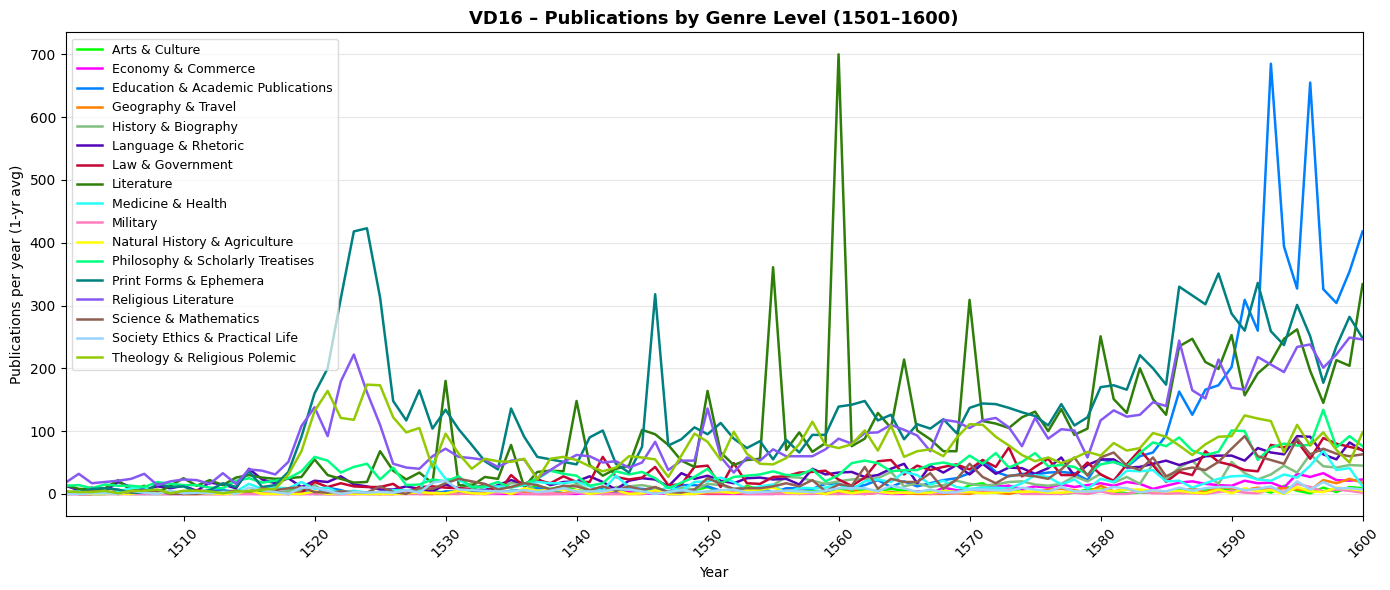

  Saved vd16_genre_timeseries.png


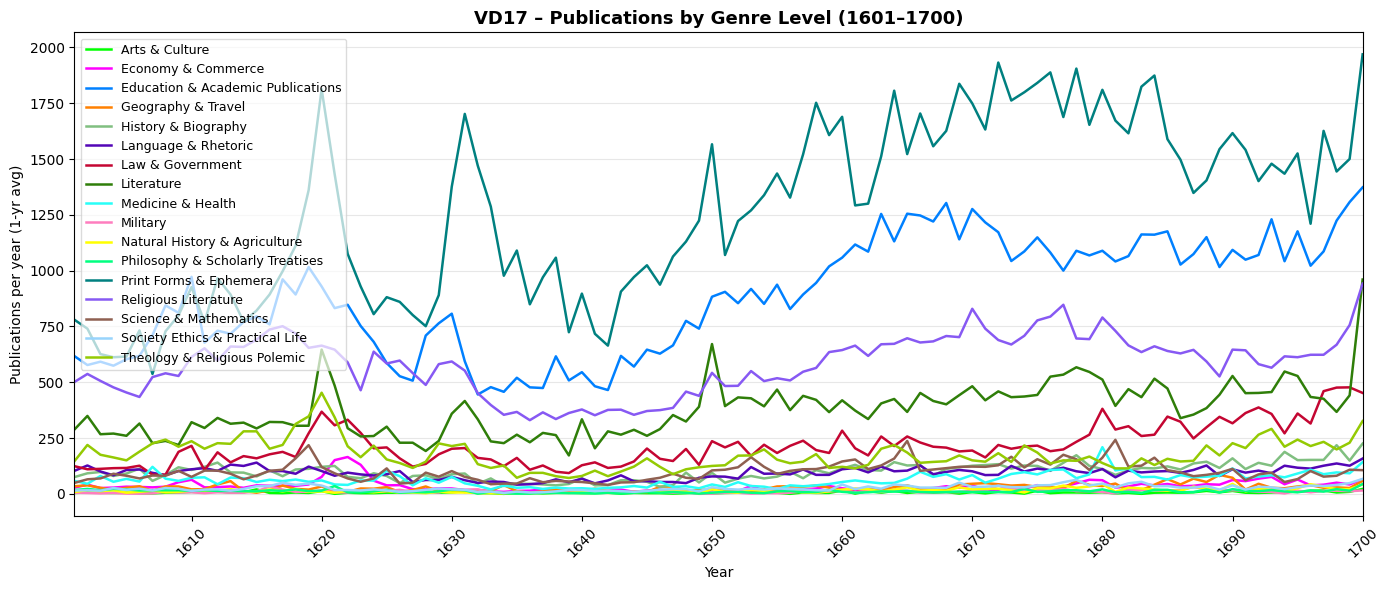

  Saved vd17_genre_timeseries.png


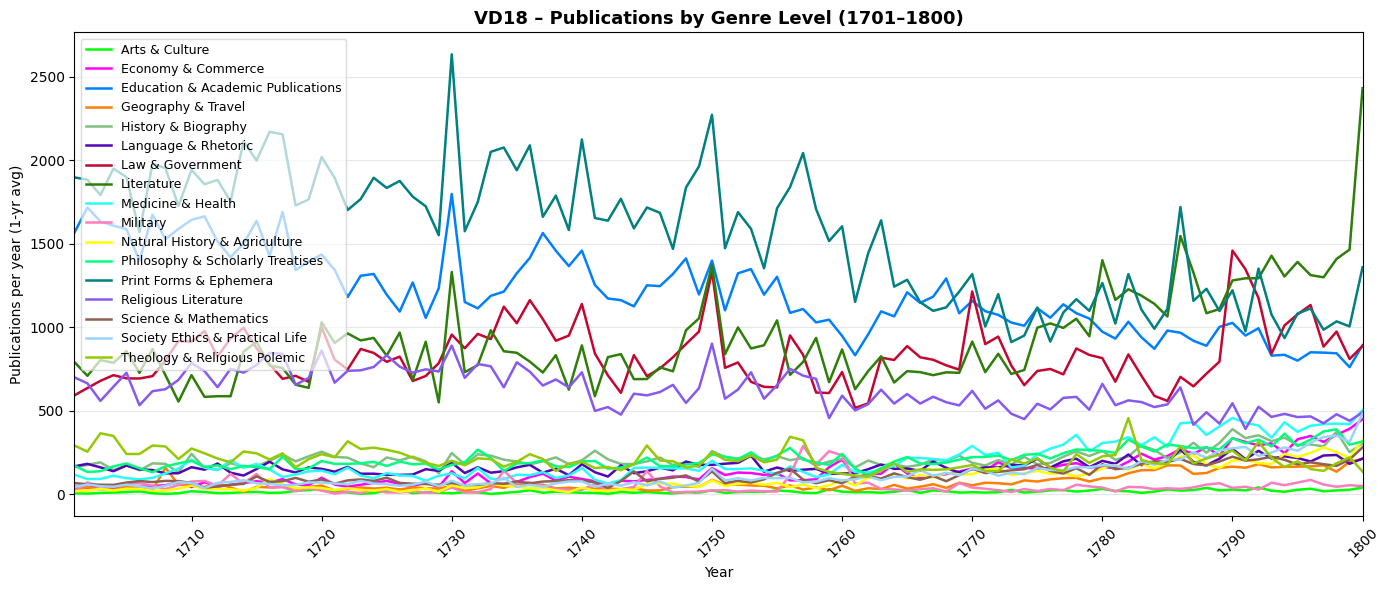

  Saved vd18_genre_timeseries.png


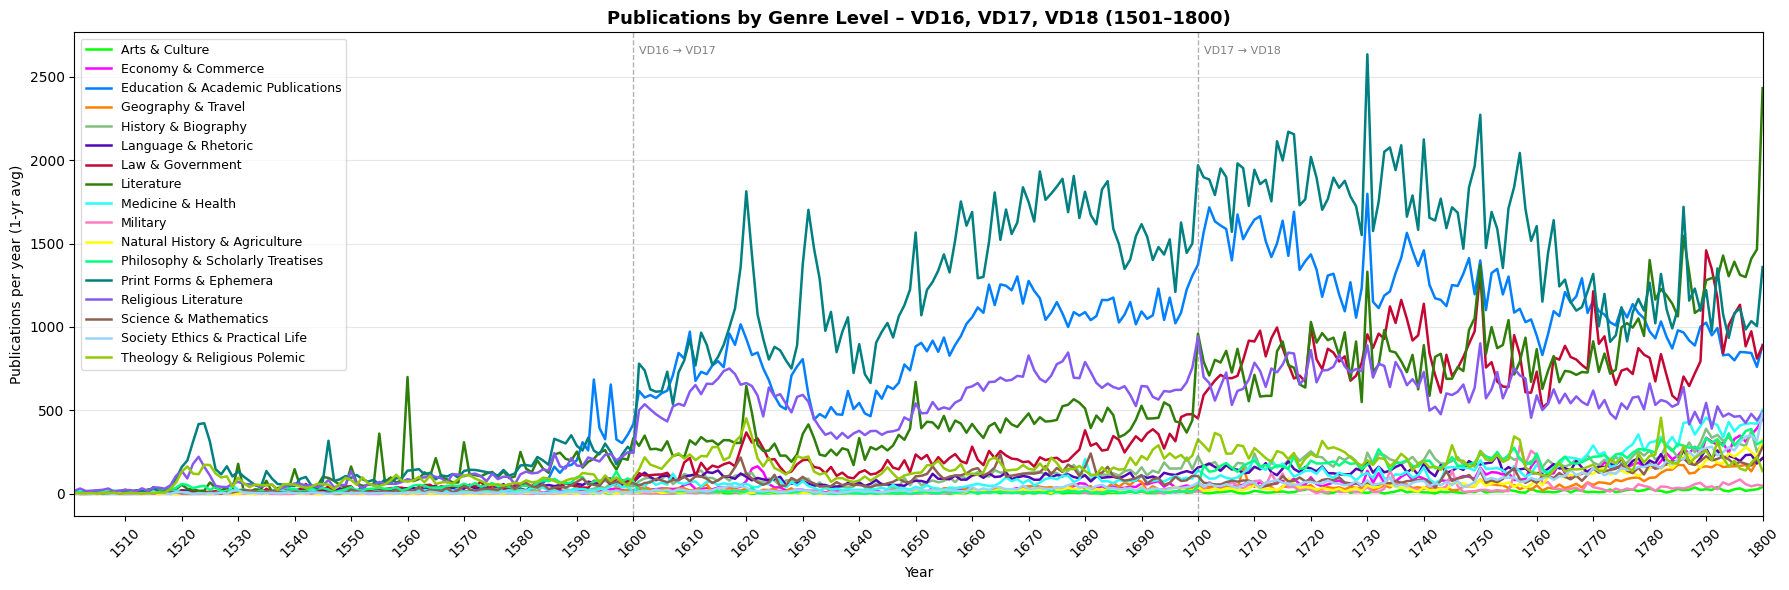

Saved combined_genre_timeseries.png


In [28]:
# Create time series visualizations for the different genres
# Done both separately for each dataset and a combined one
# Uses the Level 1 categories from hackathon_genre_categorization.csv

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import distinctipy

# ── Load genre mapping ──────────────────────────────────────────────────────
genre_df = pd.read_csv(here("data/input/hackathon_genre_categorization.csv"))
genre_df = genre_df[["german_genre_term", "Level1"]].dropna(subset=["german_genre_term", "Level1"])
genre_df["german_genre_term"] = genre_df["german_genre_term"].str.strip()
genre_to_level1 = dict(zip(genre_df["german_genre_term"], genre_df["Level1"]))

canonical_genres = set(genre_to_level1.keys())
genre_list_sql = ", ".join(f"'{g.replace(chr(39), chr(39)*2)}'" for g in canonical_genres)

# ── Extract time series from one dataset ───────────────────────────────────
def get_time_series(table_name, year_min, year_max):
    years_df = con.sql(f"""
        SELECT DISTINCT record_number, TRY_CAST(value AS INTEGER) AS year
        FROM "{table_name}"
        WHERE field_code = '011@'
          AND subfield_code = 'a'
          AND regexp_matches(value, '^\d{{4}}$')
          AND TRY_CAST(value AS INTEGER) BETWEEN {year_min} AND {year_max}
    """).df()

    genres_df = con.sql(f"""
        SELECT record_number, TRIM(value) AS genre
        FROM "{table_name}"
        WHERE field_code = '044S'
          AND subfield_code = 'a'
          AND TRIM(value) IN ({genre_list_sql})
    """).df()

    merged = years_df.merge(genres_df, on="record_number")
    merged["Level1"] = merged["genre"].map(genre_to_level1)
    merged = merged.dropna(subset=["Level1"])

    ts = merged.groupby(["year", "Level1"]).size().reset_index(name="count")
    return ts

# ── Collect data ────────────────────────────────────────────────────────────
datasets = {
    "vd16": (1501, 1600),
    "vd17": (1601, 1700),
    "vd18": (1701, 1800),
}

all_data = {}
for table_name, (year_min, year_max) in datasets.items():
    print(f"Processing {table_name}...")
    all_data[table_name] = get_time_series(table_name, year_min, year_max)

# ── Shared styling ──────────────────────────────────────────────────────────
all_levels = sorted({
    level for df in all_data.values() for level in df["Level1"].unique()
})
palette   = plt.cm.tab10.colors
distinct_colors = distinctipy.get_colors(len(all_levels))
color_map = {lvl: distinct_colors[i] for i, lvl in enumerate(all_levels)}
SMOOTH    = 1   # rolling-average window (years); set to 1 to disable

plots_dir = here("data/output/plots")
plots_dir.mkdir(parents=True, exist_ok=True)

def make_pivot(df, year_min, year_max):
    pivot = df.pivot_table(index="year", columns="Level1", values="count", fill_value=0)
    pivot = pivot.reindex(range(year_min, year_max + 1), fill_value=0)
    if SMOOTH > 1:
        pivot = pivot.rolling(SMOOTH, center=True, min_periods=1).mean()
    return pivot

# ── Individual charts ───────────────────────────────────────────────────────
for table_name, (year_min, year_max) in datasets.items():
    pivot = make_pivot(all_data[table_name], year_min, year_max)

    fig, ax = plt.subplots(figsize=(14, 6))
    for level in pivot.columns:
        ax.plot(pivot.index, pivot[level], label=level,
                color=color_map[level], linewidth=1.8)

    ax.set_title(f"{table_name.upper()} – Publications by Genre Level ({year_min}–{year_max})",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel(f"Publications per year ({SMOOTH}-yr avg)")
    ax.set_xlim(year_min, year_max)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
    ax.tick_params(axis="x", rotation=45)
    ax.legend(loc="upper left", fontsize=9, framealpha=0.7)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(plots_dir / f"{table_name}_genre_timeseries.png", dpi=150)
    plt.show()
    print(f"  Saved {table_name}_genre_timeseries.png")

# ── Combined chart ──────────────────────────────────────────────────────────
combined = pd.concat(all_data.values())
pivot_all = make_pivot(combined, 1501, 1800)

fig, ax = plt.subplots(figsize=(18, 6))
for level in pivot_all.columns:
    ax.plot(pivot_all.index, pivot_all[level], label=level,
            color=color_map[level], linewidth=1.8)

# Dataset boundary markers
for boundary, label in [(1600, "VD16 → VD17"), (1700, "VD17 → VD18")]:
    ax.axvline(boundary, color="gray", linestyle="--", linewidth=1, alpha=0.6)
    ax.text(boundary + 1, ax.get_ylim()[1] * 0.97, label,
            fontsize=8, color="gray", va="top")

ax.set_title("Publications by Genre Level – VD16, VD17, VD18 (1501–1800)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel(f"Publications per year ({SMOOTH}-yr avg)")
ax.set_xlim(1501, 1800)
ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
ax.tick_params(axis="x", rotation=45)
ax.legend(loc="upper left", fontsize=9, framealpha=0.7)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(plots_dir / "combined_genre_timeseries.png", dpi=150)
plt.show()
print("Saved combined_genre_timeseries.png")

Top 20 from handpicked

Frankfurt, Main *
Leipzig
Augsburg
Nürnberg
Köln
Wittenberg
Jena
Straßburg
Berlin
Halle, Saale * 
Helmstedt
Hamburg
Dresden
Rostock
Wien
Tübingen
Erfurt
Basel
Göttingen
München

\* These two have two variations

Halle, Saale / Halle (Saale)
Frankfurt am Main / Frankfurt, Main